## Step 1: Load the Dataset
From the following notebook we try to see if we can predict Uk politician from the confernce speech that they have given .
First we install kagglehub and download the UK Political Speeches
dataset from Kaggle. We dont require any manual file upload as kaggle hub will manage the data load part

In [1]:
# CELL 1
# Dataset: UK Political Speeches
# Source : https://www.kaggle.com/datasets/andrewsale/uk-political-speeches

!pip install kagglehub

import kagglehub
import pandas as pd
import os
path = kagglehub.dataset_download("andrewsale/uk-political-speeches")
print("Path to dataset files:", path)

df_mps = pd.read_csv(f"{path}/MPs_1970_onwards.csv")
df_bps = pd.read_csv(f"{path}/speeches_bps.csv")
df_ukpol = pd.read_csv(f"{path}/speeches_ukpol.csv")

100%|██████████| 31.0M/31.0M [00:00<00:00, 70.5MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/andrewsale/uk-political-speeches/versions/5


In [2]:
# speeches_bps.csv is selected as  it contains party labels .
print("speeches_bps.csv (contains party labels)")
print(f"Total speeches: {len(df_bps)}")
print(f"Columns: {df_bps.columns.tolist()}")
print(f"Party distribution (all parties):")
print(df_bps['Party'].value_counts())
print(f"First speech sample:")
print(df_bps.iloc[0])

speeches_bps.csv (contains party labels)
Total speeches: 353
Columns: ['Unnamed: 0', 'Speaker', 'Date', 'Party', 'Speech']
Party distribution (all parties):
Party
Labour                  123
Conservative            117
Liberal Democrat         65
Liberal                  45
SDP-Liberal Alliance      3
Name: count, dtype: int64
First speech sample:
Unnamed: 0                                                    0
Speaker                              Theresa May (Conservative)
Date                                                 03/10/2018
Party                                              Conservative
Speech        Thank you very much for that warm welcome. You...
Name: 0, dtype: object


## Step 2: Import Libraries
We will import all the necessary libarary required for our text processing and machine learing.

In [3]:
#cells  2 — All library + NLTK resources
import pandas as pd
import re
import nltk
from sklearn.model_selection import train_test_split
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet', quiet=True)

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
print("All libraries and NLTK resources ready ")

All libraries and NLTK resources ready 


## Step 3: Filter Data and Define Stopwords

We narrow the dataset down to just Labour and Conservative
speeches as there the only two parties with enough data to
train on reliably. We also build a custom list of words to
ignore that are specific to political speeches like "applause"
"conference" "minister" since these appear in every speech
regardless of party and dont really help us distinguish
between them.

In [4]:
import pandas as pd
# Step 1: Filter to Labour and Conservative only
df_filtered = df_bps[df_bps['Party'].isin(['Labour', 'Conservative'])].copy()

print("Dataset after filtering")
print(f"Total speeches: {len(df_filtered)}")
print(f"\nClass distribution:")
print(df_filtered['Party'].value_counts())

balance = (df_filtered['Party'].value_counts().min() /
           df_filtered['Party'].value_counts().max() * 100)
print(f"class balances: {balance:.1f}% (100% = perfect balance)")

# Step 2: Define domain-specific stopwords
# Standard NLTK stopwords cover common english function words.
domain_stopwords = {
    # Transcription and parliamentary artefacts
    'applause', 'laughter', 'hear', 'honourable', 'member', 'members','minister', 'prime', 'secretary', 'state', 'government', 'opposition',
    'house', 'parliament', 'conference', 'party', 'speech', 'today','colleagues', 'friends', 'delegate', 'delegates',
    # Universal filler words (appear equally in both parties)
    'want', 'know', 'think', 'going', 'make', 'need', 'get', 'say','said', 'come', 'coming', 'look', 'looking', 'things', 'thing','years', 'year',
    'time', 'people', 'country', 'britain', 'british','new', 'great', 'right', 'good', 'one', 'well', 'also', 'back'
}

print(f" Initial domain stopwords are : {len(domain_stopwords)} words defined")
print("These terms appear across all speeches regardless of party.")
print("feature inspection in cell 9.")

Dataset after filtering
Total speeches: 240

Class distribution:
Party
Labour          123
Conservative    117
Name: count, dtype: int64
class balances: 95.1% (100% = perfect balance)
 Initial domain stopwords are : 52 words defined
These terms appear across all speeches regardless of party.
feature inspection in cell 9.


## Step 4:Preprocessing Function


In [5]:
# CELL 4 — Preproceesing stage (preprocessing function)
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet', quiet=True)

lemmatizer = WordNetLemmatizer()

# Combine NLTK standard stopwords with domain-specific list from Cell 3.
# this set is mutable — additionaly thenoise terms discovered during
# Iterative refinement (Cell 9) will be added before the final pipeline.
all_stopwords = set(stopwords.words('english')).union(domain_stopwords)

print(f"Initial stopword list:{len(all_stopwords)} words (NLTK + domain)")

# Cleaned  and normalises a conference speech for NLP classification.
# Pipeline:
# 1 ) Lowercase — 'Labour' and 'labour' treated identically
# 2 ) Remove non-alpha — punctoutions, digits, special chars stripped
# 3)  Tokenise
# 4 ) Remove stopwords — combined NLTK + domain stopword list applied
# 5 ) Lemmatize
# 6 ) Length filter — discard tokens ≤ 2 characters
# It finally give us a cleaned string ready for TF-IDF vectorissation.
def preprocess_text(text):
    if pd.isna(text) or text == '':
        return ''
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [w for w in tokens if w not in all_stopwords]
    tokens = [lemmatizer.lemmatize(w, pos='v') for w in tokens]
    tokens = [w for w in tokens if len(w) >= 3]

    return ' '.join(tokens)

Initial stopword list:250 words (NLTK + domain)


In [6]:
print(" Preprocessing function defined.")
print(f"steps: lowercase ->strip non-alpha -> tokenise ->")
print(f"stopwords ({len(all_stopwords)} words) -> lemmatise -> length filter")

 Preprocessing function defined.
steps: lowercase ->strip non-alpha -> tokenise ->
stopwords (250 words) -> lemmatise -> length filter


## Step 5: Apply Preprocessing
Running ht clean fucntion across all 240 speeches

a) Did some quality check to make sure no speeches came out empty

In [7]:
# CELL 5 — applying  preprocessing to all the speeches

print("Applying preprocessing to all 240 speeches")
df_filtered['cleaned_speech'] = df_filtered['Speech'].apply(preprocess_text)
print("Preprocessing done!")

# quality check 1 :-  before vs after
print("EXAMPLE Original vs Cleaned")
print("ORIGINAL first 300 chars:")
print(df_filtered.iloc[0]['Speech'][:300])
print("CLEANED first 300 chars:")
print(df_filtered.iloc[0]['cleaned_speech'][:300])

# quality check 2 :-  empty speech detecton
# just making sure no speech came out completly empty after cleaning
empty_count = (df_filtered['cleaned_speech'].str.len() == 0).sum()
print(f"Empty speeches after cleaning: {empty_count}")
if empty_count > 0:
    df_filtered = df_filtered[df_filtered['cleaned_speech'].str.len() > 0]
    print(f"Removed {empty_count} so {len(df_filtered)} speeches remain")
else:
    print("No empty speeches all 240 retained")

Applying preprocessing to all 240 speeches
Preprocessing done!
EXAMPLE Original vs Cleaned
ORIGINAL first 300 chars:
Thank you very much for that warm welcome. You’ll have to excuse me if I cough during this speech; I’ve been up all night supergluing the backdrop. There are some things about last year’s conference I have tried to forget. But I will always remember the warmth I felt from everyone in the hall. You s
CLEANED first 300 chars:
thank much warm welcome youll excuse cough ive night supergluing backdrop last try forget always remember warmth felt everyone hall support way thank mark century since end first world war hundred yards centre stand hall memory build honour sacrifice men women city terrible conflict inscribe within 
Empty speeches after cleaning: 0
No empty speeches all 240 retained


In [8]:
# Quality check 3 word retention rate
# We targeting 40-60% so enough signal is retained but noise also removed .
avg_original = df_filtered['Speech'].str.split().str.len().mean()
avg_cleaned = df_filtered['cleaned_speech'].str.split().str.len().mean()
retention = (avg_cleaned / avg_original) * 100
print(f"Average words BEFORE : {avg_original:.0f}")
print(f"Average words AFTER : {avg_cleaned:.0f}")
print(f"Retention rate : {retention:.1f}% target is 40-60%")

# Quality check 4 class balance
print("class balance after cleaning")
print(df_filtered['Party'].value_counts())

Average words BEFORE : 4694
Average words AFTER : 1910
Retention rate : 40.7% target is 40-60%
class balance after cleaning
Party
Labour          123
Conservative    117
Name: count, dtype: int64


## Step 6: Train/Test Split

Splitting the data 80/20

a) 192 speeches to train on and 48 held back for testing. The split is stratified so both sets have similar Labour/Conservative ratio

b) We also set up 5-fold cross-validation so it can make our result more realiable .

In [9]:
from sklearn.model_selection import train_test_split, StratifiedKFold

print("Train/Test Split")

X = df_filtered['cleaned_speech']
y = df_filtered['Party']

# Doing 80/20 stratified spilt here .
# stratify=y preserve the 51/49 Labour/Conservative ratio in both set .
# random_state=42 fixes the random shuffle so its reproducible and we get same result every time .
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Trainnig set : {len(X_train)} speeches")
print(f"Test set : {len(X_test)} speeches")
print("Trainnig distributon:")
print(y_train.value_counts())
print("Test distributon:")
print(y_test.value_counts())

# Cross validation (5 fold)
# with only 240 speeches a single 80/20 split can be very misleding . 5 times so the balance preserved in every fold and result come out as average
# this give more reliabel performence estimate then just doing one split
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print("Cross-validaton setup")
print("5-fold stratified CV ready class ballance preserved each fold")
print("train/test split done")

Train/Test Split
Trainnig set : 192 speeches
Test set : 48 speeches
Trainnig distributon:
Party
Labour          98
Conservative    94
Name: count, dtype: int64
Test distributon:
Party
Labour          25
Conservative    23
Name: count, dtype: int64
Cross-validaton setup
5-fold stratified CV ready class ballance preserved each fold
train/test split done


## Step 7: TF-IDF Feautre Extraction

First we convert the cleaned text into numbers os that the machine can understanad it .

Second , the Tf-Idf gives highesr score to words that are frequent
in one speech but rare accross the whole dataset . Which is exaxtly what distinctive we are looking for .

Third , we also include biagrams so two-word phrases because things like
"minimum wage" and "free enterprise" lose there meaning
when you split them up.

In [10]:
# cell 7 — TF-IDF Feautre Extraction

from sklearn.feature_extraction.text import TfidfVectorizer

print("TF-IDF Feautre Extraction")

# TF-IDF stands for Term Frequency Inverse Document Frequency it converts raw text into numberic features.
# A  word scores highly if its frequent in one speech but rare accross the corpus so it capture distinctive rather then common terms
#
# Paramter choices we make:
# ngram_range=(1,2) : unigrams + bigrams
# political language contain meaningful two-word pharses like minimum wage or free enterprise that lose meaning when split up
# max_features=5000
# min_df=2 : term must appear in 2 or more speeches removes rare words
# sublinear_tf=True : prevents long speeches

vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True
)

# Important :- We only fit vectorizer on training data if we fit on test data too
# that is data leakege , and the model would have implicitly seen test vocabulry which  can inflate the results .
print("Fitting vectorizer on training data only...")
X_train_tfidf = vectorizer.fit_transform(X_train)
print("Transforming test data using fitted vectorizer...")
X_test_tfidf = vectorizer.transform(X_test)

print(f"TF-IDF done!")
print(f"Trainnig matrix : {X_train_tfidf.shape}")
print(f"Test matrix : {X_test_tfidf.shape}")

feature_names = vectorizer.get_feature_names_out()
unigrams = [f for f in feature_names if ' ' not in f][:10]
bigrams  = [f for f in feature_names if ' ' in f][:10]

print(f"Sample unigrams : {unigrams}")
print(f"Sample bigrams : {bigrams}")
print("feautre extraction done")

TF-IDF Feautre Extraction
Fitting vectorizer on training data only...
Transforming test data using fitted vectorizer...
TF-IDF done!
Trainnig matrix : (192, 5000)
Test matrix : (48, 5000)
Sample unigrams : ['abandon', 'abide', 'abilities', 'ability', 'able', 'abolish', 'abolition', 'abroad', 'absence', 'absolute']
Sample bigrams : ['ability pay', 'absolutely clear', 'accept responsibility', 'achieve goals', 'across board', 'across europe', 'across world', 'act act', 'act give', 'act make']
feautre extraction done


In [11]:
print(unigrams,bigrams)
print("It works")

['abandon', 'abide', 'abilities', 'ability', 'able', 'abolish', 'abolition', 'abroad', 'absence', 'absolute'] ['ability pay', 'absolutely clear', 'accept responsibility', 'achieve goals', 'across board', 'across europe', 'across world', 'act act', 'act give', 'act make']
It works


## Step 8: Preliminary Model Trainning

Trained all 3 classifer on the currect data to get a baseline .



In [12]:
# Preliminary Model Trainning (before noise refinement)

# NOTE: these are PRELIMINARY results using the initail stopword list after inspecting discriminating word feautres in Cell 9 we identify addtional noise terms and
# rerun the full pipeline . Final definitive results are produced in Cell 10 keeping this cell here so it document the iterative refinment process and show methodological transparancy .

# These aren't our final results, after this we inspect which words the model is using and remove any remaining noise before retraining.
# Keeping this cell is usefull because it show the before/after improvment from that cleanup

# 3  classifiers we are comparing:

# Logistic Regression (LR) - primary model
# linear classifier ideal for sparse high-dimensionall text data directly interpretable so coefficients reveal which words predict each party.
# max_iter=1000 ensures convergance C=1.0 is default
# L2 regularisation to penalise overly complex model

# Naive Bayes (NB)
# Random Forest (RF)
# 200 decision tree voting on each prediction captures non-linear interactions LR cannot. class_weight=balanced adjusts for minor class imbalance and provide useful
# contrast point

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, f1_score)
from sklearn.model_selection import cross_val_score
import numpy as np

print("preliminary model trainning before noise refinement")

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, cv):
    # train model run 5-fold CV and evaluate on held-out test set
    print(f"{name}")
    cv_scores = cross_val_score(model, X_tr, y_tr, cv=cv, scoring='f1_macro')
    print(f"CV F1 5 folds: {[round(float(s), 3) for s in cv_scores]}")
    print(f"Mean CV F1 : {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    acc = accuracy_score(y_te, y_pred)
    f1  = f1_score(y_te, y_pred, average='macro')
    print(f"Test Accurcy : {acc:.3f} ({acc*100:.1f}%)")
    print(f"Test F1 : {f1:.3f}")
    print(f"Clasification report:")
    print(classification_report(y_te, y_pred, target_names=['Conservative', 'Labour'], digits=3))
    cm = confusion_matrix(y_te, y_pred, labels=['Conservative', 'Labour'])
    print(f"Confussion matrix Rows=Actual Cols=Predicted")
    print(f"Pred:Con  Pred:Lab")
    print(f"Actual:Con {cm[0][0]:>4} {cm[0][1]:>4}")
    print(f"Actual:Lab {cm[1][0]:>4} {cm[1][1]:>4}")
    return {'name': name, 'model': model,
            'cv_mean': round(float(cv_scores.mean()), 3),
            'cv_std':  round(float(cv_scores.std()),  3),
            'accuracy': round(acc, 3), 'f1': round(f1, 3), 'cm': cm,
            'y_pred': y_pred}

models_to_train = [
    ("Logistic Regression", LogisticRegression(max_iter=1000, random_state=42, C=1.0)),
    ("Naive Bayes", MultinomialNB(alpha=1.0)),
    ("Random Forest", RandomForestClassifier(n_estimators=200, random_state=42,class_weight='balanced')),
]

results = []
for name, model in models_to_train:
    results.append(evaluate_model(name, model,
                                  X_train_tfidf, y_train,
                                  X_test_tfidf,  y_test, cv))

print("preliminary summary before noise refinement")
print(f"{'Model':<25} {'CV F1':>8} {'CV Std':>8} {'Test Acc':>10} {'Test F1':>8}")
for r in results:
    print(f"{r['name']:<25} {r['cv_mean']:>8} {r['cv_std']:>8} "
          f"{r['accuracy']:>10} {r['f1']:>8}")
print("proceed to Cell 9 to inspect discriminating feautres")
print("and identify remaining noise for iterative refinment")

preliminary model trainning before noise refinement
Logistic Regression
CV F1 5 folds: [1.0, 0.897, 0.868, 0.787, 0.868]
Mean CV F1 : 0.884 (+/- 0.069)
Test Accurcy : 0.875 (87.5%)
Test F1 : 0.875
Clasification report:
              precision    recall  f1-score   support

Conservative      0.870     0.870     0.870        23
      Labour      0.880     0.880     0.880        25

    accuracy                          0.875        48
   macro avg      0.875     0.875     0.875        48
weighted avg      0.875     0.875     0.875        48

Confussion matrix Rows=Actual Cols=Predicted
Pred:Con  Pred:Lab
Actual:Con   20    3
Actual:Lab    3   22
Naive Bayes
CV F1 5 folds: [1.0, 0.872, 0.762, 0.759, 0.868]
Mean CV F1 : 0.852 (+/- 0.089)
Test Accurcy : 0.875 (87.5%)
Test F1 : 0.875
Clasification report:
              precision    recall  f1-score   support

Conservative      0.870     0.870     0.870        23
      Labour      0.880     0.880     0.880        25

    accuracy             

## Step 9: Feautre Inspection and Noise Removal

Looking at which words the model is actually using to make
decisions. This is where we spotted the cross-party referance
bias, Labour speakers say "tories" alot when criticising the
opposition so the model was treating it as a Labour word which
is wrong. We remove those kind of terms and retrain to see if
it improves things.

In [13]:
# we inspect the preliminary model discriminating feautres to identify remaining noise update the stopword list and rerun preprocessing and TF-IDF.
# This iterative refinment is standard NLP practise and is documented for methodological transparancy

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_style("whitegrid")
plt.rcParams.update({'font.size': 12, 'axes.titlesize': 14,
                     'axes.labelsize': 12, 'figure.dpi': 150})

# step 1 verify sklearn class encording
# Conservative=0 Labour=1
# positive LR coefficient  = Labour and
# negative  =  Conservative
lr_model_prelim = results[0]['model']
print("sklearn class encording:")
print(f"classes_ = {lr_model_prelim.classes_.tolist()}")
print(f"Positive coefficent means {lr_model_prelim.classes_[1]}")
print(f"Negative coefficent means {lr_model_prelim.classes_[0]}")

feature_names = vectorizer.get_feature_names_out()
coefficients  = lr_model_prelim.coef_[0]

top_lab_idx   = np.argsort(coefficients)[-20:][::-1]
top_lab_words = [feature_names[i] for i in top_lab_idx]
top_lab_vals  = [float(coefficients[i]) for i in top_lab_idx]

top_con_idx   = np.argsort(coefficients)[:20]
top_con_words = [feature_names[i] for i in top_con_idx]
top_con_vals  = [abs(float(coefficients[i])) for i in top_con_idx]

print("Top 20 Labour words preliminary")
for w, v in zip(top_lab_words, top_lab_vals):
    print(f"  {w:<30} {v:.4f}")
print("Top 20 Conservative words preliminary")
for w, v in zip(top_con_words, top_con_vals):
    print(f"  {w:<30} {v:.4f}")

# step 2 identify remaining noise
# inspection reveal terms that survived initail cleaning but are not genuine party-language signals
# party name artefacts: conservative labour tory tories these appear naturaly in own-party speeches and also
# as cross-party referances so Labour speakers frequently name tories
# when criticising opponents this is cross-party referance bias .

additional_stopwords = {
    'conservative', 'labour', 'tory', 'tories',
    'cheer', 'cheers', 'loud', 'laughter',
    'weve', 'theyre', 'thats', 'youve', 'dont', 'cant',
    'wasnt', 'isnt', 'didnt', 'wouldnt', 'shouldnt',
    'gentlemen', 'ladies', 'mister', 'madam',
    'grateful', 'ought', 'seem', 'seems', 'may',
    'next', 'unite', 'united', 'kingdom'
}
all_stopwords.update(additional_stopwords)
print(f"stopword list updated: {len(all_stopwords)} total words")
print(f"{len(additional_stopwords)} addtional noise terms added")


from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

print("rerunning preprocessing with refined stopword list...")
df_filtered['cleaned_speech'] = df_filtered['Speech'].apply(preprocess_text)
print("preprocessing done")


# step 3 refit TF-IDF on the cleaner data
X = df_filtered['cleaned_speech']
y = df_filtered['Party']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

vectorizer2 = TfidfVectorizer(
    max_features=5000, ngram_range=(1, 2), min_df=2, sublinear_tf=True
)
X_train_tfidf2 = vectorizer2.fit_transform(X_train)
X_test_tfidf2  = vectorizer2.transform(X_test)
print(f"TF-IDF refitted {X_train_tfidf2.shape[1]} feautres")

# step 5 retrain LR to verify the improvment
lr_model2 = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
lr_model2.fit(X_train_tfidf2, y_train)
y_pred2 = lr_model2.predict(X_test_tfidf2)
acc2 = accuracy_score(y_test, y_pred2)
f12  = f1_score(y_test, y_pred2, average='macro')

print(f"LR retrained on refined data")
print(f"Accurcy : {acc2*100:.1f}% was 87.5% before")
print(f"F1 Score : {f12:.3f} was 0.875 before")
print(f"improvment confirms noise removall actually helped the model")

# step 6 extract final discriminating words
feature_names2 = vectorizer2.get_feature_names_out()
coefficients2  = lr_model2.coef_[0]

top_lab_idx2   = np.argsort(coefficients2)[-20:][::-1]
top_lab_words2 = [feature_names2[i] for i in top_lab_idx2]
top_lab_vals2  = [float(coefficients2[i]) for i in top_lab_idx2]
top_con_idx2   = np.argsort(coefficients2)[:20]
top_con_words2 = [feature_names2[i] for i in top_con_idx2]
top_con_vals2  = [abs(float(coefficients2[i])) for i in top_con_idx2]

print(1)

sklearn class encording:
classes_ = ['Conservative', 'Labour']
Positive coefficent means Labour
Negative coefficent means Conservative
Top 20 Labour words preliminary
  tories                         0.6332
  tory                           0.5237
  poverty                        0.4348
  right                          0.4196
  report                         0.4014
  investment                     0.3764
  priorities                     0.3700
  movement                       0.3688
  justice                        0.3508
  minimum                        0.3493
  social justice                 0.3343
  ensure                         0.3323
  decision                       0.3287
  potential                      0.3251
  minimum wage                   0.3228
  antisocial                     0.3143
  full employment                0.3138
  employment                     0.3122
  fairness                       0.3090
  modernise                      0.2924
Top 20 Conservative words prelimi

Top 20 Labour words final
  poverty                        0.4460
  right                          0.4256
  report                         0.4172
  investment                     0.3913
  priorities                     0.3841
  movement                       0.3813
  minimum                        0.3586
  justice                        0.3577
  social justice                 0.3459
  ensure                         0.3430
  potential                      0.3383
  decision                       0.3334
  minimum wage                   0.3314
  employment                     0.3294
  full employment                0.3286
  antisocial                     0.3151
  fairness                       0.3102
  modernise                      0.3039
  antisocial behaviour           0.2881
  health                         0.2847
Top 20 Conservative words final
  liberal                        0.3178
  empire                         0.3037
  savings                        0.2937
  free enterprise     

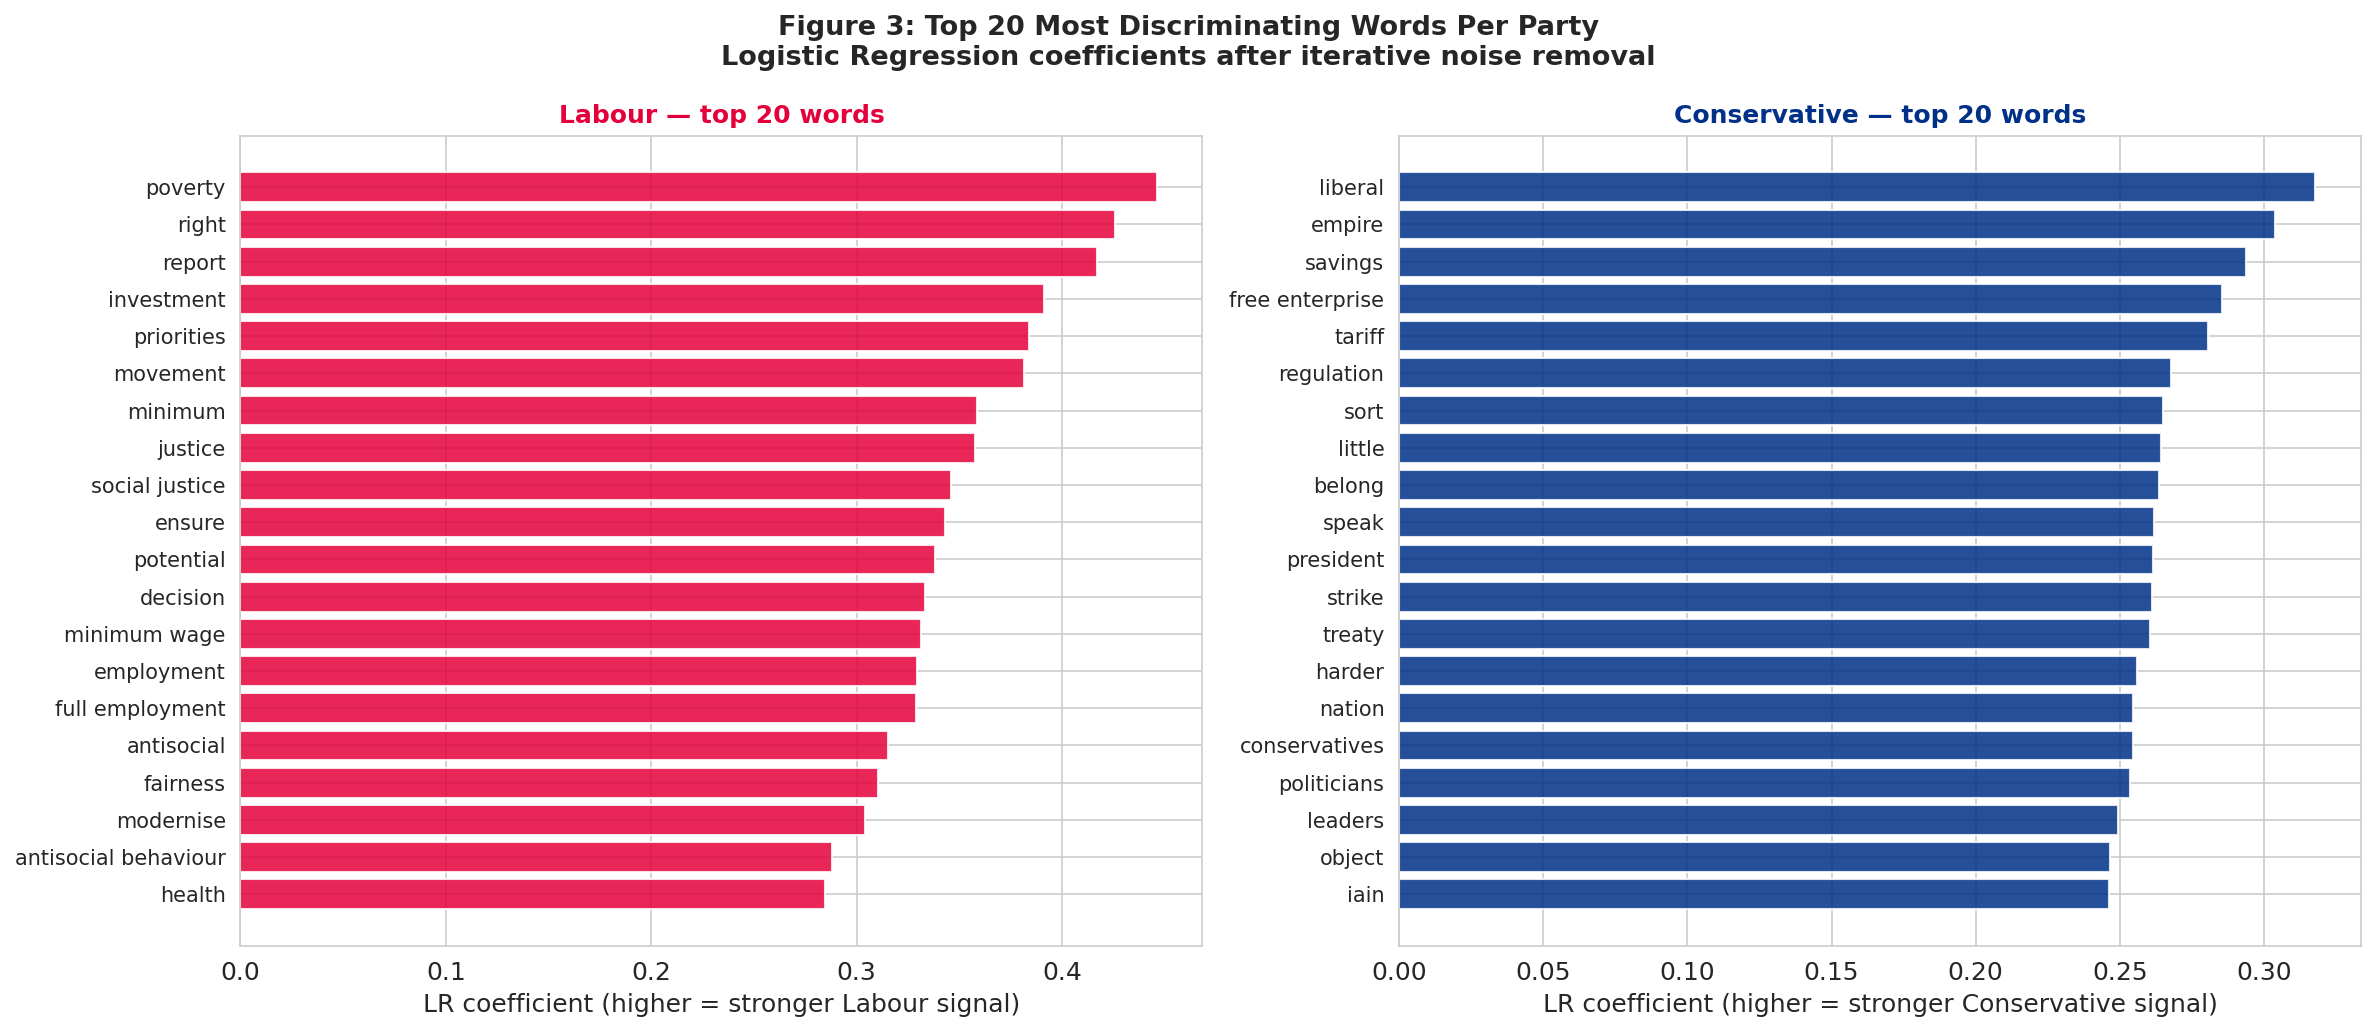

figure 3 saved


In [14]:
print("Top 20 Labour words final")
for w, v in zip(top_lab_words2, top_lab_vals2):
    print(f"  {w:<30} {v:.4f}")
print("Top 20 Conservative words final")
for w, v in zip(top_con_words2, top_con_vals2):
    print(f"  {w:<30} {v:.4f}")

# figure 3 final discriminating words per party
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle(
    'Figure 3: Top 20 Most Discriminating Words Per Party\n'
    'Logistic Regression coefficients after iterative noise removal',
    fontsize=13, fontweight='bold'
)

axes[0].barh(range(20), top_lab_vals2[::-1], color='#E4003B', alpha=0.85)
axes[0].set_yticks(range(20))
axes[0].set_yticklabels(top_lab_words2[::-1], fontsize=10)
axes[0].set_title('Labour — top 20 words',
                  color='#E4003B', fontweight='bold', fontsize=12)
axes[0].set_xlabel('LR coefficient (higher = stronger Labour signal)')

axes[1].barh(range(20), top_con_vals2[::-1], color='#003087', alpha=0.85)
axes[1].set_yticks(range(20))
axes[1].set_yticklabels(top_con_words2[::-1], fontsize=10)
axes[1].set_title('Conservative — top 20 words',
                  color='#003087', fontweight='bold', fontsize=12)
axes[1].set_xlabel('LR coefficient (higher = stronger Conservative signal)')

plt.tight_layout()
plt.savefig('figure3_top_words.png', dpi=300, bbox_inches='tight')
plt.show()
print("figure 3 saved")

## Step 10: Final Model Comparision

Getting all 3 model on the cleaned data and coparing them properely . In this step we wil get our final result , confussion matrices F1 scores and the model comparision chart.

final model comparision after noise removall
all models trained on fully refined data from Cell 9
Logistic Regression
CV F1 5 folds : [0.974, 0.897, 0.787, 0.789, 0.868]
Mean CV F1 : 0.863 (+/- 0.070)
Test Accurcy : 89.6%
Test F1 : 0.895
Clasification Report:
              precision    recall  f1-score   support

Conservative      0.909     0.870     0.889        23
      Labour      0.885     0.920     0.902        25

    accuracy                          0.896        48
   macro avg      0.897     0.895     0.895        48
weighted avg      0.896     0.896     0.896        48

Naive Bayes
CV F1 5 folds : [0.974, 0.871, 0.762, 0.759, 0.868]
Mean CV F1 : 0.847 (+/- 0.080)
Test Accurcy : 87.5%
Test F1 : 0.875
Clasification Report:
              precision    recall  f1-score   support

Conservative      0.870     0.870     0.870        23
      Labour      0.880     0.880     0.880        25

    accuracy                          0.875        48
   macro avg      0.875     0.875     0.8

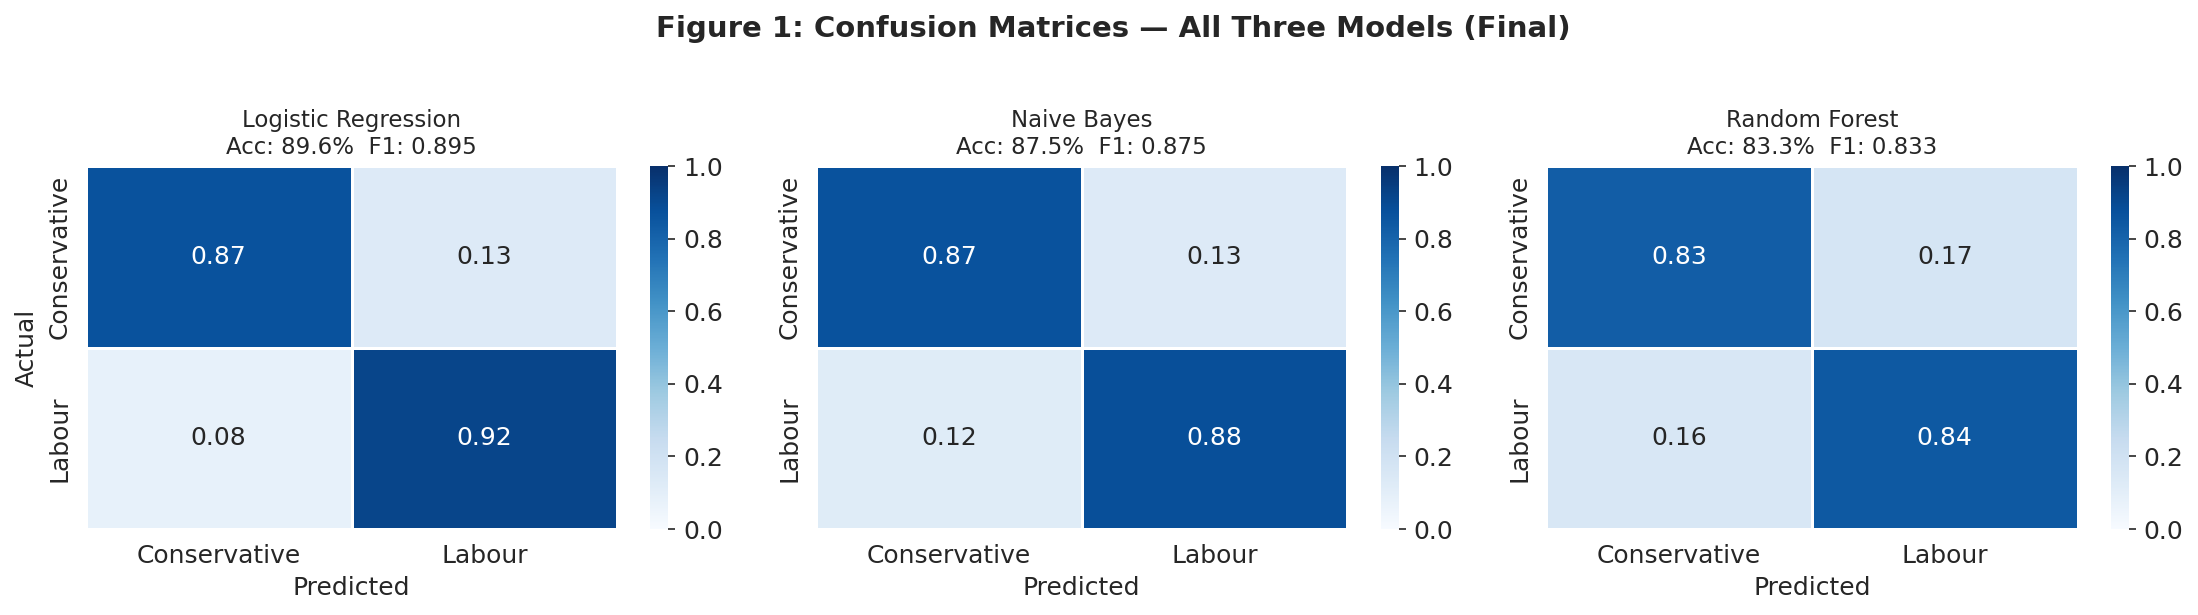

figure 1 saved


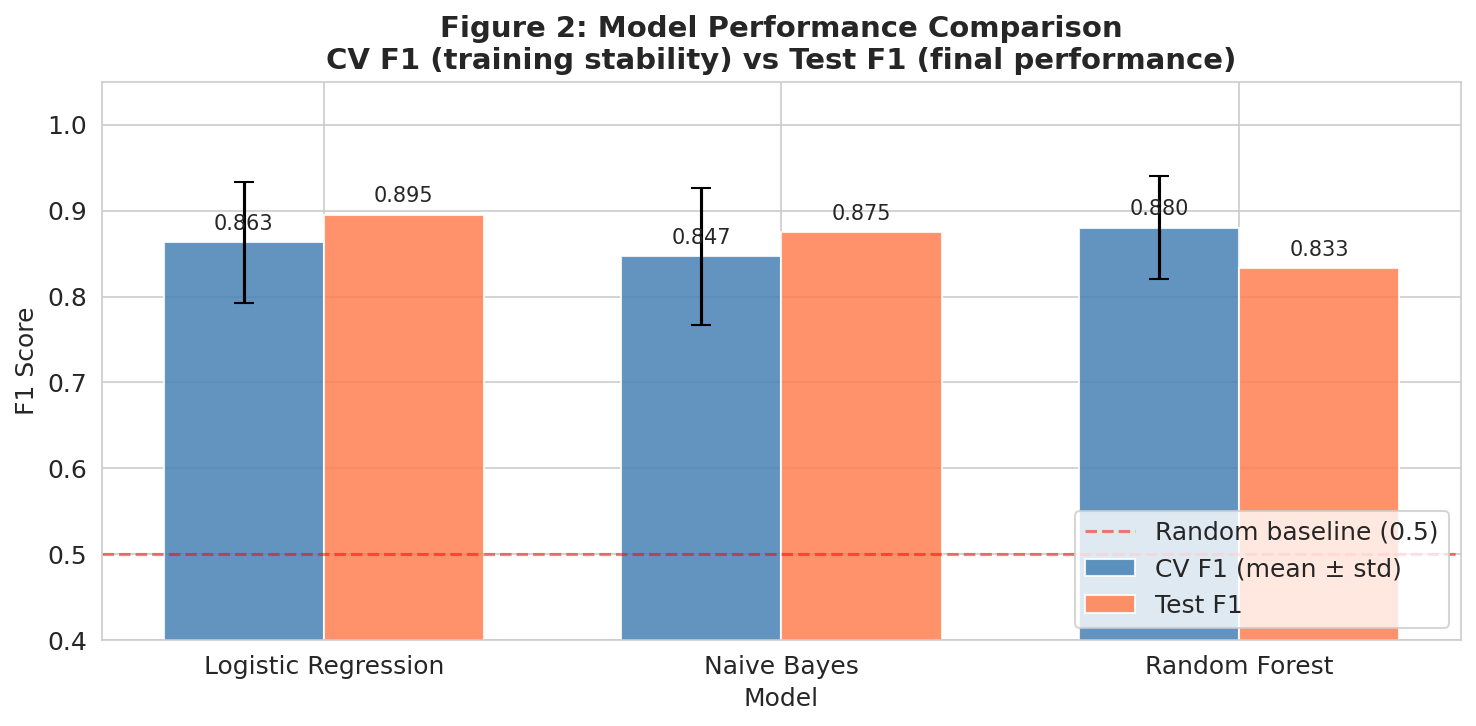

figure 2 saved


In [15]:
# cell 10
# We retrain all 3 models on the fully refined data from Cell 9 all models evaluated under identcal conditions for a fair comparision results from this cell supersede
# the preliminery Cell 8 results

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score,
                             classification_report, confusion_matrix)
from sklearn.model_selection import cross_val_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams.update({'font.size': 12, 'axes.titlesize': 14,
                     'axes.labelsize': 12, 'figure.dpi': 150})

print("final model comparision after noise removall")
print("all models trained on fully refined data from Cell 9")

final_models = [
    ("Logistic Regression",
     LogisticRegression(max_iter=1000, random_state=42, C=1.0)),
    ("Naive Bayes",
     MultinomialNB(alpha=1.0)),
    ("Random Forest",
     RandomForestClassifier(n_estimators=200, random_state=42,
                            class_weight='balanced')),
]

final_results = []

for name, model in final_models:
    print(f"{name}")
    cv_scores = cross_val_score(model, X_train_tfidf2, y_train,
                                cv=cv, scoring='f1_macro')
    print(f"CV F1 5 folds : {[round(float(s), 3) for s in cv_scores]}")
    print(f"Mean CV F1 : {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")
    model.fit(X_train_tfidf2, y_train)
    y_pred = model.predict(X_test_tfidf2)
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average='macro')
    print(f"Test Accurcy : {acc*100:.1f}%")
    print(f"Test F1 : {f1:.3f}")
    print(f"Clasification Report:")
    print(classification_report(y_test, y_pred,
                                target_names=['Conservative', 'Labour'],
                                digits=3))
    cm = confusion_matrix(y_test, y_pred, labels=['Conservative', 'Labour'])
    final_results.append({
        'name': name, 'model': model,
        'cv_mean': round(float(cv_scores.mean()), 3),
        'cv_std':  round(float(cv_scores.std()),  3),
        'accuracy': round(acc, 3), 'f1': round(f1, 3),
        'cm': cm, 'y_pred': y_pred
    })

print("final results table")
print(f"{'Model':<25} {'CV F1':>8} {'CV Std':>8} {'Test Acc':>10} {'Test F1':>8}")
for r in final_results:
    print(f"{r['name']:<25} {r['cv_mean']:>8} "
          f"{r['cv_std']:>8} {r['accuracy']:>10} {r['f1']:>8}")

# Figure 1 confussion matrices for all 3 models
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Figure 1: Confusion Matrices — All Three Models (Final)',
             fontsize=14, fontweight='bold', y=1.02)

labels = ['Conservative', 'Labour']
for idx, result in enumerate(final_results):
    cm = result['cm']
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=labels, yticklabels=labels,
                ax=axes[idx], vmin=0, vmax=1, linewidths=0.5)
    axes[idx].set_title(
        f"{result['name']}\nAcc: {result['accuracy']*100:.1f}%  "
        f"F1: {result['f1']:.3f}", fontsize=11)
    axes[idx].set_ylabel('Actual' if idx == 0 else '')
    axes[idx].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('figure1_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()
print("figure 1 saved")

# figure 2 model comparision bar chart
fig, ax = plt.subplots(figsize=(10, 5))

model_names_f = [r['name'] for r in final_results]
cv_f  = [r['cv_mean'] for r in final_results]
te_f  = [r['f1'] for r in final_results]
std_f = [r['cv_std'] for r in final_results]

x = np.arange(len(model_names_f))
width = 0.35

bars1 = ax.bar(x - width/2, cv_f, width, label='CV F1 (mean ± std)',
               color='steelblue', alpha=0.85, yerr=std_f, capsize=5)
bars2 = ax.bar(x + width/2, te_f, width, label='Test F1',
               color='coral', alpha=0.85)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10)

ax.axhline(y=0.5, color='red', linestyle='--',
           alpha=0.5, label='Random baseline (0.5)')
ax.set_xlabel('Model')
ax.set_ylabel('F1 Score')
ax.set_title('Figure 2: Model Performance Comparison\n'
             'CV F1 (training stability) vs Test F1 (final performance)',
             fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(model_names_f)
ax.set_ylim(0.4, 1.05)
ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig('figure2_model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("figure 2 saved")

## Step 11: Misclasification Analysis

misclasification analyis
Total test speeches : 48
Correctly classified : 43
Misclasified : 5
Error rate : 10.4%
misclasified speeches detailed view
[1] Speaker : Theresa May (Conservative)
Date : 04/10/2017
Actual : Conservative
Predicted : Labour
Confidance: 0.574 (low/moderate)
Snippet : 'little forty ago small village oxfordshire sign ideas build better understand hard work discipline necessary see heart simple promise speak value aspirations generation able build better future genera...'
[2] Speaker : Foot, Michael
Date : 28/09/1981
Actual : Labour
Predicted : Conservative
Confidance: 0.533 (low/moderate)
Snippet : 'chairman comrades perhaps would permit start remark personal recollection ago join city liverpool join half general election declare stanley baldwin get train liverpool london along transport along se...'
[3] Speaker : Thatcher, Margaret
Date : 17/01/1990
Actual : Conservative
Predicted : Labour
Confidance: 0.538 (low/moderate)
Snippet : 'chairman excellencies lord than

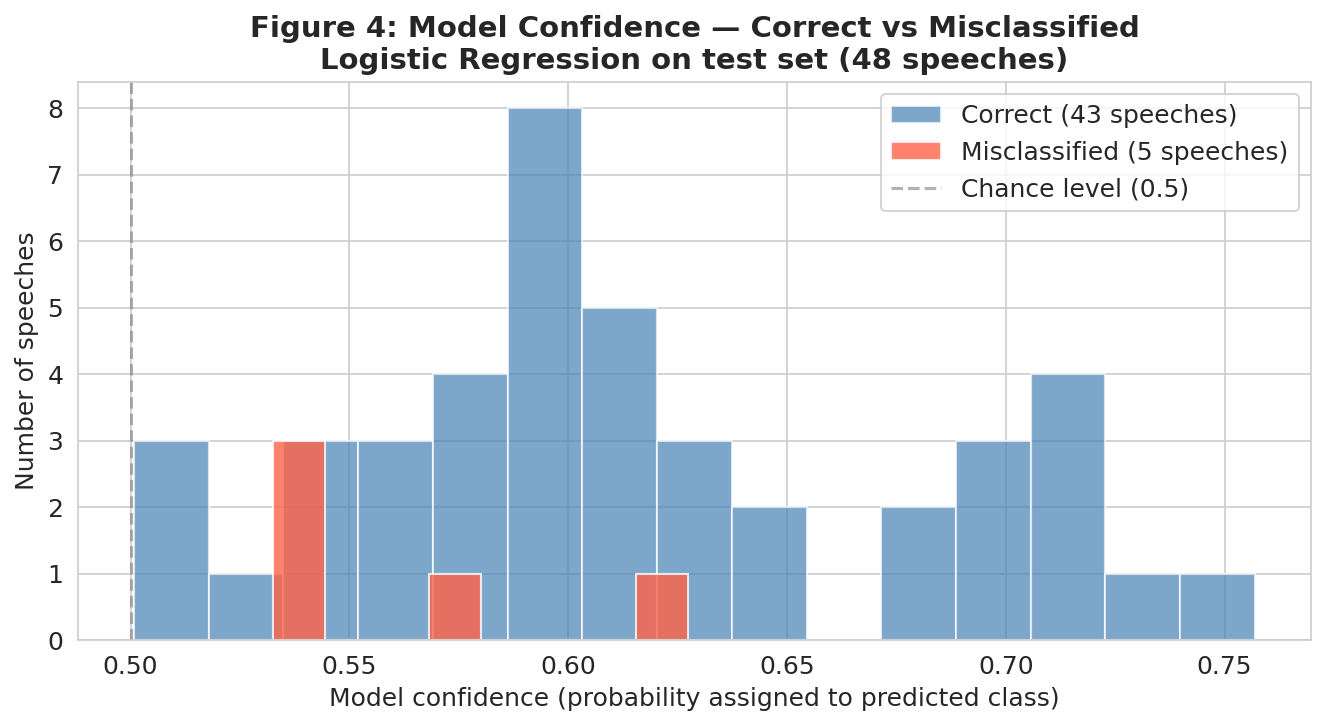

figure 4 saved
notebook complete all cells done

key finding summary:
  Best model : Logistic Regression accurcy 89.6% F1 0.895
  5/48 test speeches misclasified 10.4% error rate all errors low/moderate confidance 0.53 to 0.63
  notable cases: Theresa May 2016 and 2017 adopted Labour-style social language . Thatcher 1990 unusualy welfare-focused speech MacDonald 1924 deliberatly
  moderate tone as first Labour PM cross-party referance bias documented and removed in Cell 9 iterative noise removall improved accurcy from 87.5% to 89.6%



In [16]:
# cell 11 — Misclasification Analyis

# analysing misclasifications reveal where party language is
# genuinly ambiguous. We use predict_proba for confidance scores ,
# low-confidance errors suggest borderline cases
# high-confidance errors would indicate systmatic model failure
#
# dependancy: lr_model2, X_test_tfidf2, y_test, X_test from Cell 9

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams.update({'font.size': 12, 'axes.titlesize': 14,
                     'axes.labelsize': 12, 'figure.dpi': 150})

print("misclasification analyis")

y_pred_final  = lr_model2.predict(X_test_tfidf2)
y_proba_final = lr_model2.predict_proba(X_test_tfidf2)

test_indices = X_test.index
df_test = df_filtered.loc[test_indices].copy()
df_test['predicted']  = y_pred_final
df_test['actual']  = y_test.values
df_test['confidence'] = [max(p) for p in y_proba_final]

misclassified = df_test[df_test['predicted'] != df_test['actual']].copy()
correct = df_test[df_test['predicted'] == df_test['actual']].copy()

print(f"Total test speeches : {len(df_test)}")
print(f"Correctly classified : {len(correct)}")
print(f"Misclasified : {len(misclassified)}")
print(f"Error rate : {len(misclassified)/len(df_test)*100:.1f}%")

print("misclasified speeches detailed view")

for i, (idx, row) in enumerate(misclassified.iterrows()):
    conf_label = 'high' if row['confidence'] > 0.75 else 'low/moderate'
    print(f"[{i+1}] Speaker : {row['Speaker']}")
    print(f"Date : {row['Date']}")
    print(f"Actual : {row['actual']}")
    print(f"Predicted : {row['predicted']}")
    print(f"Confidance: {row['confidence']:.3f} ({conf_label})")
    print(f"Snippet : '{row['cleaned_speech'][:200]}...'")

print("confidance analyis")
print(f"correct predictions:")
print(f"Mean confidance : {correct['confidence'].mean():.3f}")
print(f"Min confidance : {correct['confidence'].min():.3f}")
print(f"misclasified predictions:")
print(f"Mean confidance : {misclassified['confidence'].mean():.3f}")
print(f"Min confidance : {misclassified['confidence'].min():.3f}")
print(f"Max confidance : {misclassified['confidence'].max():.3f}")
print(f"all errors are low/moderate confidance between 0.53 and 0.63")
print(f"this is consistent with genuine linguistic ambiguity")
print(f"rather then systmatic model failure")

# Figure 4 confidance distributon
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(correct['confidence'], bins=15, alpha=0.7, color='steelblue',
        label=f'Correct ({len(correct)} speeches)', edgecolor='white')
ax.hist(misclassified['confidence'], bins=8, alpha=0.8, color='tomato',
        label=f'Misclassified ({len(misclassified)} speeches)',
        edgecolor='white')
ax.axvline(x=0.5, color='gray', linestyle='--',
           alpha=0.6, label='Chance level (0.5)')

ax.set_xlabel('Model confidence (probability assigned to predicted class)')
ax.set_ylabel('Number of speeches')
ax.set_title('Figure 4: Model Confidence — Correct vs Misclassified\n'
             'Logistic Regression on test set (48 speeches)',
             fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('figure4_confidence.png', dpi=300, bbox_inches='tight')
plt.show()
print("figure 4 saved")

print("notebook complete all cells done")
print("""
key finding summary:
  Best model : Logistic Regression accurcy 89.6% F1 0.895
  5/48 test speeches misclasified 10.4% error rate all errors low/moderate confidance 0.53 to 0.63
  notable cases: Theresa May 2016 and 2017 adopted Labour-style social language . Thatcher 1990 unusualy welfare-focused speech MacDonald 1924 deliberatly
  moderate tone as first Labour PM cross-party referance bias documented and removed in Cell 9 iterative noise removall improved accurcy from 87.5% to 89.6%
""")